<a href="https://colab.research.google.com/github/ChandanGurjar/Exploratory-Data-Analysis-EDA-ML-Models/blob/main/Regression-Projects/ACME_Insurance_Medical_Expenditure_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The following topics are covered in this Presentation:

1. A typical problem statement for machine learning
2. Downloading and exploring a dataset for machine learning
3. Linear regression with one variable using Scikit-learn
4. Linear regression with multiple variables
5. Using categorical features for machine learning
6. Regression coefficients and feature importance
7. Other models and techniques for regression using Scikit-learn



#Problem Statement

This problem takes a practical and coding-focused approach. We'll define the terms machine learning and linear regression in the context of a problem,
and later generalize their definitions. We'll work through a typical machine learning problem step-by-step:

**QUESTION**: ACME Insurance Inc. offers affordable health insurance to thousands of customer all over the United States.
 As the lead data scientist at ACME, you're tasked with creating an automated system to estimate the annual medical expenditure for new customers,
 using information such as their age, sex, BMI, children, smoking habits and region of residence.

Estimates from your system will be used to determine the annual insurance premium (amount paid every month) offered to the customer. Due to regulatory requirements, you must be able to explain why your system outputs a certain prediction.

You're given a CSV file containing verified historical data,
consisting of the aforementioned information and the actual medical charges incurred by over 1300 customers.

datasetLinkAdress="https://jovian.com/outlink?url=https%3A%2F%2Fgithub.com%2Fstedy%2FMachine-Learning-with-R-datasets"

'''

In [ ]:





medical_charges_url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'




In [ ]:
from urllib.request import urlretrieve
urlretrieve(medical_charges_url, 'medical.csv')

import pandas as pd
medical_df=pd.read_csv('medical.csv')

medical_df




,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


'''
The dataset contains 1338 rows and 7 columns. Each row of the dataset contains information about one customer.
Our objective is to find a way to estimate the value in the "charges" column using the values in the other columns.
If we can do so for the historical data, then we should able to estimate charges for new customers too,
simply by asking for information like their age, sex, BMI, no. of children, smoking habits and region.
'''


In [ ]:
# Let's check the data type for each column.
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Looks like "age", "children", "bmi" (body mass index) and "charges" are numbers, whereas "sex", "smoker" and "region" are strings (possibly categories). None of the columns contain any missing values, which saves us a fair bit of work!


Here are some statistics for the numerical columns:

In [ ]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


The ranges of values in the numerical columns seem reasonable too (no negative ages!), so we may not have to do much data cleaning or correction. The "charges" column seems to be significantly skewed however, as the median (50 percentile) is much lower than the maximum value.



# Exploratory Analysis and Visualization
Now we will explore the data by visualizing the distribution of values in some columns of the dataset, and the relationships between "charges" and other columns.

We'll use libraries Matplotlib, Seaborn and Plotly for visualization





In [ ]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

The following settings will improve the default style and font sizes for our charts.

In [ ]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'



#Age
 Age is a numeric column. The minimum age in the dataset is 18 and the maximum age is 64. Thus, we can visualize the distribution of age using a histogram with 47 bins (one for each year) and a box plot. We'll use plotly to make the chart interactive, but you can create similar charts using Seaborn.

In [ ]:
medical_df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [ ]:
fig = px.histogram(medical_df,
                   x='age',
                   marginal='box',
                   nbins=47,
                   title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

The distribution of ages in the dataset is almost uniform, with 20-30 customers at every age, except for the ages 18 and 19, which seem to have over twice as many customers as other ages. The uniform distribution might arise from the fact that there isn't a big variation in the number of people of any given age (between 18 & 64) in the USA.







#Body Mass Index
Let's look at the distribution of BMI (Body Mass Index) of customers, using a histogram and box plot.




In [ ]:
fig=px.histogram(medical_df,
                 x='bmi',
                 marginal='box',
                 color_discrete_sequence=['red'],
                 title='Distribution of BMI(Body Mass Index)')
fig.update_layout(bargap=0.1)
fig.show()

The measurements of body mass index seem to form a [Gaussian distribution] centered around the value 30, with a few outliers towards the right.

#Charges
here  we have visualized the distribution of "charges" i.e. the annual medical charges for customers. This is the column we're trying to predict. we also use the categorical column "smoker" to distinguish the charges for smokers and non-smokers.




In [ ]:

fig=px.histogram(medical_df,
                 x='charges',
                 marginal='box',
                 color='smoker',
                 color_discrete_sequence=['green','grey'],
                 title='Annual Medical Charges')

fig.update_layout(bargap=0.1)
fig.show()

We can make the following observations from the above graph:

For most customers, the annual medical charges are under \$10,000. Only a small fraction of customer have higher medical expenses, possibly due to accidents, major illnesses and genetic diseases.
There is a significant difference in medical expenses between smokers and non-smokers. While the median for non-smokers is
7300,the median for smokers is close to
35,000.



# Smoker

let's also  visualize the distribution of the 'smoker' column (containing values "yes" and "no")

using a histogram

In [ ]:
medical_df.smoker.value_counts()


no     1064
yes     274
Name: smoker, dtype: int64

In [ ]:
px.histogram(medical_df,x='smoker',color='sex',title='Smoker')

It appears that 20% of customers have reported that they smoke. Can you verify whether this matches the national average, assuming the data was collected in 2010? We can also see that smoking appears a more common habit among males


#Age and Charges
 Now Let's visualize the relationship between "age" and "charges" using a scatter plot. Each point in the scatter plot represents one customer. We'll also use values in the "smoker" column to color the points.



In [ ]:
fig=px.scatter(medical_df,
               x='age',
               y='charges',
               color='smoker',
               opacity=0.8,
               hover_data=['sex'],
               title='Age vs Charges')

fig.update_traces(marker_size=5)
fig.show()




We can make the following observations from the above chart:

* The general trend seems to be that
medical charges increase with age, as we might expect. However, there is significant variation at every age, and it's clear that age alone cannot be used to accurately determine medical charges.

* We can see three "clusters" of points, each of which seems to form a line with an increasing slope:

1. The first and the largest cluster
consists primary of presumably "healthy non-smokers" who have relatively low medical charges compared to others

2. The second cluster contains a mix of smokers and non-smokers. It's possible that these are actually two distinct but overlapping clusters: "non-smokers with medical issues" and "smokers without major medical issues".

3. The final cluster consists exclusively of smokers, presumably smokers with major medical issues that are possibly related to or worsened by smoking.




#BMI and Charges
Let's visualize the relationship between BMI (body mass index) and charges using another scatter plot. Once again, we'll use the values from the "smoker" column to color the points.

In [ ]:
fig=px.scatter(medical_df,
               x='bmi',
               y='charges',
               color='smoker',
               opacity=0.8,
               hover_data=['sex'],
               title='BMI vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

We can see that for non-smokers, an increase in BMI doesn't seem to be related to an increase in medical charges. However, medical charges seem to be significantly higher for smokers with a BMI greater than 30.


#Correlation
As you can tell from the analysis, the values in some columns are more closely related to the values in "charges" compared to other columns. E.g. "age" and "charges" seem to grow together, whereas "bmi" and "charges" don't.


In [ ]:
medical_df.charges.corr(medical_df.age)

0.2990081933306476

In [ ]:
medical_df.charges.corr(medical_df.bmi)


0.19834096883362895



To compute the correlation for categorical columns, they must first be converted into numeric columns.

In [ ]:
smoker_values={'no':0,'yes':1}
smoker_numeric=medical_df.smoker.map(smoker_values)
medical_df.charges.corr(smoker_numeric)

0.787251430498478

**Strength**: The greater the absolute value of the correlation coefficient, the stronger the relationship.

* The extreme values of -1 and 1 indicate a perfectly linear relationship where a change in one variable is accompanied by a perfectly consistent change in the other. For these relationships, all of the data points fall on a line. In practice, you won’t see either type of perfect relationship.

* A coefficient of zero represents no linear relationship. As one variable increases, there is no tendency in the other variable to either increase or decrease.

* When the value is in-between 0 and +1/-1, there is a relationship, but the points don’t all fall on a line. As r approaches -1 or 1, the strength of the relationship increases and the data points tend to fall closer to a line.


**Direction**:The sign of the correlation coefficient represents the direction of the relationship.

* Positive coefficients indicate that when the value of one variable increases, the value of the other variable also tends to increase. Positive relationships produce an upward slope on a scatterplot.

* Negative coefficients represent cases when the value of one variable increases, the value of the other variable tends to decrease. Negative relationships produce a downward slope.

In [ ]:
medical_df.corr()

<ipython-input-69-cf93875bab50>:1: FutureWarning:

The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.



,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


The result of `.corr` is called a correlation matrix and is often visualized using a heatmap.

<ipython-input-70-dddcf7169793>:1: FutureWarning:

The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.



Text(0.5, 1.0, 'Correlation Matrix')

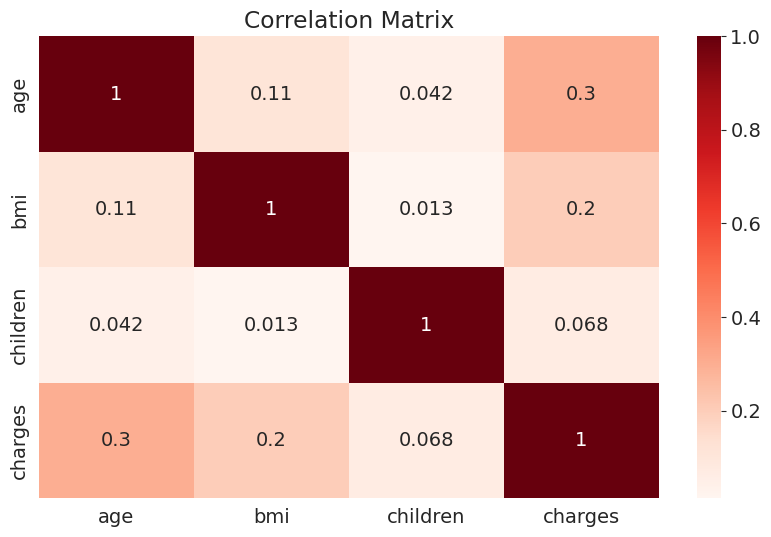

In [ ]:
sns.heatmap(medical_df.corr(),cmap='Reds',annot=True)
plt.title('Correlation Matrix')

#Linear Regression using a Single Feature

We now know that the "smoker" and "age" columns have the strongest correlation with "charges". Let's try to find a way of estimating the value of "charges" using the value of "age" for non-smokers.and also using the values of'age' for smokers First, we have created a data frame containing just the data for non-smokers.
and then for data frame containing just the data for smokers.

In [ ]:
non_smoker_df=medical_df[medical_df.smoker=='no']


In [ ]:
smoker_df=medical_df[medical_df.smoker=='yes']

Now let's visualize  the relationship between 'age' and 'charges'
Using the non_smoker_df dataframe


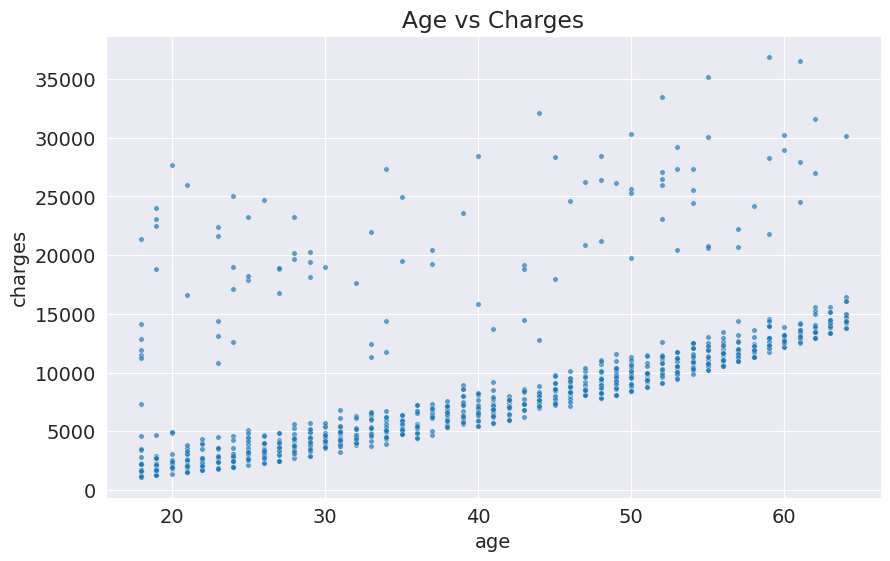

In [ ]:
plt.title('Age vs Charges')
sns.scatterplot(data=non_smoker_df,x='age',y='charges',alpha=0.7,s=15);

 As we can see apart from a few exceptions, the points seem to form a line. We'll try and "fit" a line using this points, and use the line to predict charges for a given age. we all know that a line on the X&Y coordinates has the following formula
y=wx+b

 As we have studied That  line is characterized by two numbers:
w (called "slope") and
b (called "intercept").

Now let's also visualize the relationship between 'age' and 'charges' Using the smoker_df dataFrame

<Axes: title={'center': 'Age  vs. Charges'}, xlabel='age', ylabel='charges'>

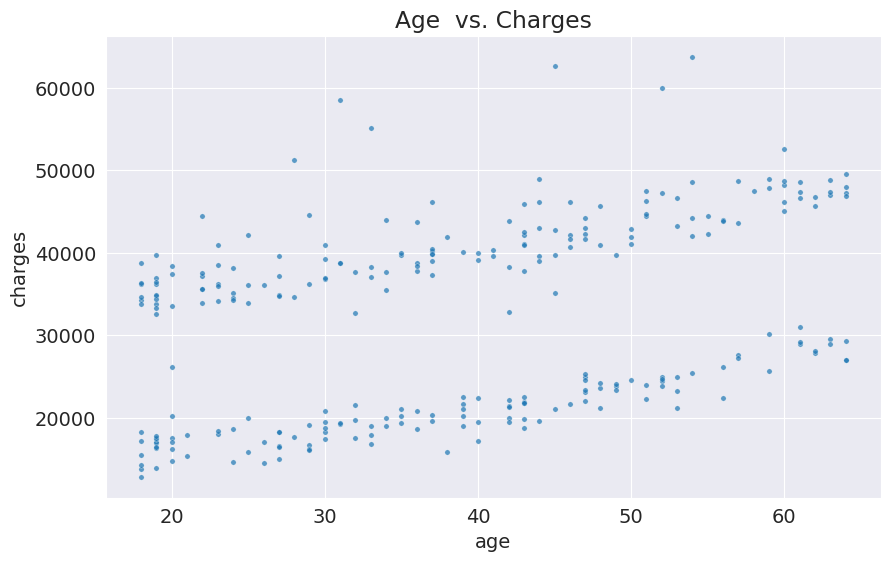

In [ ]:
plt.title('Age  vs. Charges')
sns.scatterplot(data=smoker_df,x='age',y='charges',alpha=0.7,s=15)


#Model
In the above case, the x axis shows "age" and the y axis shows "charges". Thus, we can assume the following relationship between the two:

charges=w×age+b

Now we have to determine the w and b for the line that best fits the data.

* The technique we are using in this model is called linear Regression , and we call the above equation a linear regression model, because it models the relationship between "age" and "charges" as a straight line.

* The numbers w and b are called the parameters or weights of the model.

* The values in the "age" column of the dataset are called the inputs to the model and the values in the charges column are called "targets".

Now we are going to  define a helper function  estimate_charges, to compute
charges, given :
age,w and b.

for both the smoker_df and nonsmoker_df

In [ ]:
 # For the non-smokers
def nonsmoker_estimate_charges(age,w,b):
  return w*age+b



In [ ]:
# For the smokers

def smoker_estimate_charges(age,w,b):
  return w*age+b



The nonsmoker_estimate_charges function is our very first model.

Let's guess the values for
w and
b and use them to estimate the value for charges.

In [ ]:
w=50
b=100
ageNonSmoker=non_smoker_df.age
estimated_chargesNonSmoker=nonsmoker_estimate_charges(ageNonSmoker,w,b)
print(estimated_chargesNonSmoker)



1       1000
2       1500
3       1750
4       1700
5       1650
        ... 
1332    2700
1333    2600
1334    1000
1335    1000
1336    1150
Name: age, Length: 1064, dtype: int64


In [ ]:
w=50
b=100
ageSmoker=smoker_df.age
estimated_chargesForSmokers=smoker_estimate_charges(ageSmoker,w,b)
print(estimated_chargesForSmokers)

0       1050
11      3200
14      1450
19      1600
23      1800
        ... 
1313    1050
1314    1600
1321    3200
1323    2200
1337    3150
Name: age, Length: 274, dtype: int64


Text(0, 0.5, 'Estimated Charges For Non Smokers')

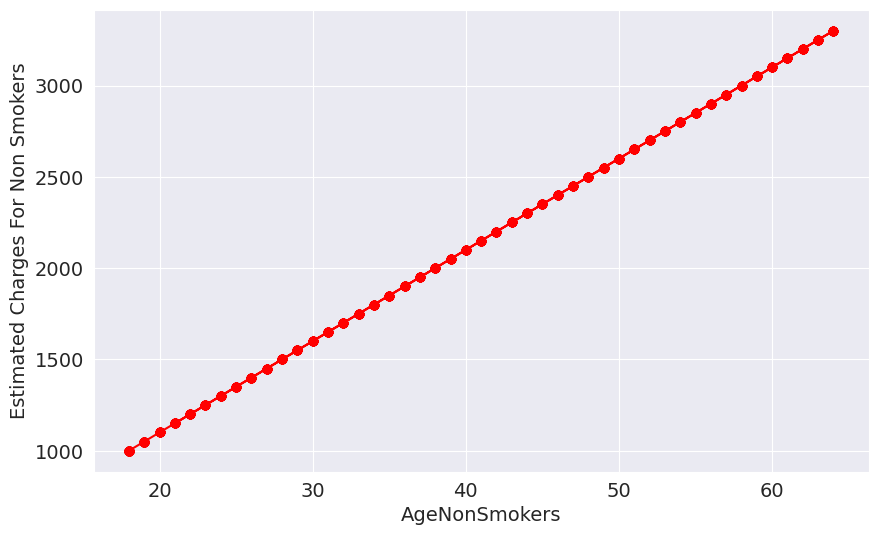

In [ ]:
# Now we can plot the estimated charges for Non-smokers  using a line graph.

plt.plot(ageNonSmoker,estimated_chargesNonSmoker,'r-o');
plt.xlabel('AgeNonSmokers')
plt.ylabel('Estimated Charges For Non Smokers')



Text(0, 0.5, 'Estimated Charges For Smokers')

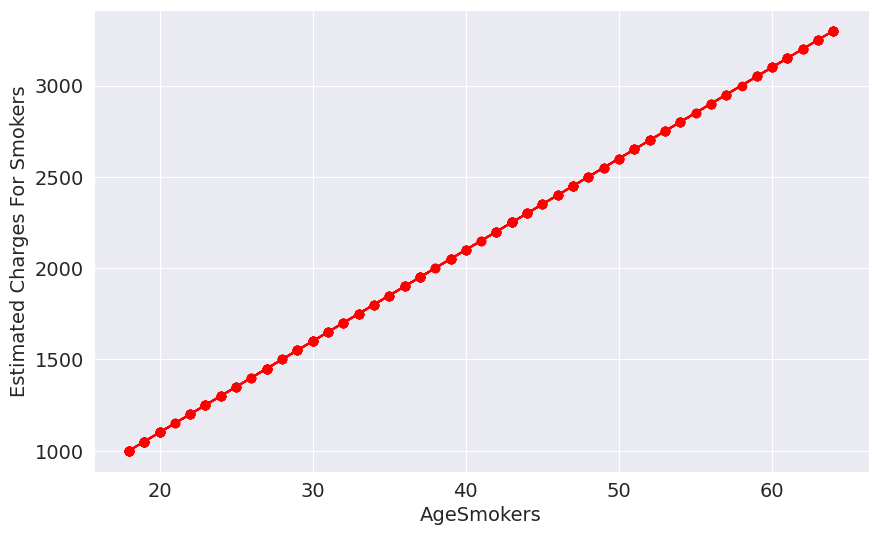

In [ ]:
# Now ploting the estimated charges for the Smokers using a line graph.

plt.plot(ageSmoker,estimated_chargesForSmokers,'r-o')
plt.xlabel('AgeSmokers')
plt.ylabel('Estimated Charges For Smokers')


As expected, the points lie on a straight line.

We can overlay this line on the actual data, so see how well our model fits the data.

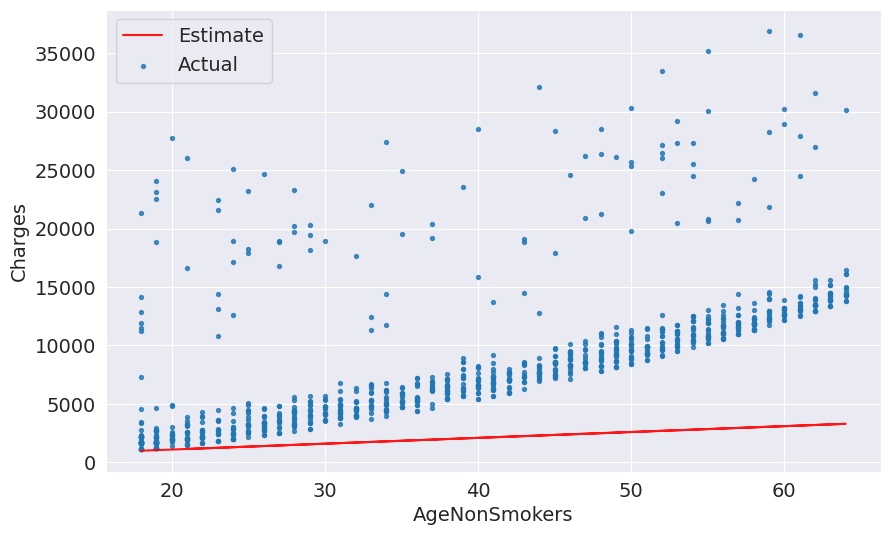

In [ ]:

# Non smokers

target=non_smoker_df.charges
plt.plot(ageNonSmoker,estimated_chargesNonSmoker,'r',alpha=0.9);
plt.scatter(ageNonSmoker,target,s=8,alpha=0.8);
plt.xlabel('AgeNonSmokers')
plt.ylabel('Charges')
plt.legend(['Estimate','Actual'])


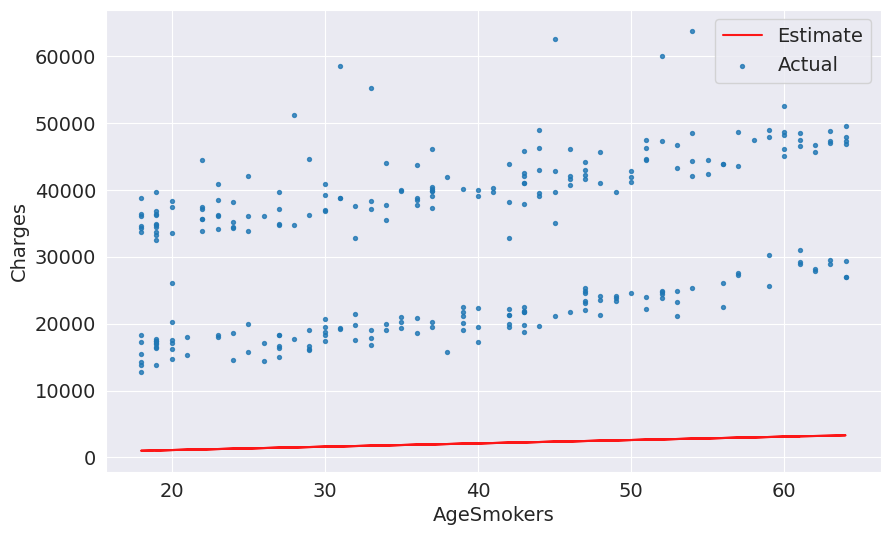

In [ ]:
# For Smokers

target=smoker_df.charges
plt.plot(ageSmoker,estimated_chargesForSmokers,'r',alpha=0.9);
plt.scatter(ageSmoker,target,s=8,alpha=0.8);
plt.xlabel('AgeSmokers')
plt.ylabel('Charges')
plt.legend(['Estimate','Actual'])

Clearly, we can see that our estimates are quite poor and the line does not "fit" the data. However, we can try different values of w and b to move the line around. For doing that Let's define a helper function try_parametersNonSmokers and try_parametersSmokers
which takes w and b as inputs and creates the above plot.


we need to solve a couple of problems:

We need a way to measure numerically how well the line fits the points.

Once the "measure of fit" has been computed, we need a way to modify w and b to improve the the fit.

If we can solve the above problems, it should be possible for a computer to determine w and b for the best fit line, starting from a random guess.



so here  we are going to define a function which is going to calculate the
loss function or the cost function the difference between the actual and predicated values

> and the technique which we are going to use is the root mean squared error (rmse)



In [ ]:
import numpy as np

def rmse(targets,predictions):
  return np.sqrt(np.mean(np.square(targets-predictions)))

# The lower the loss the better the model
# let's call this rmse function inside of the try_parameters function

In [ ]:
# For Non Smokers

def try_parametersNonSmokers(w,b):
  ageNonSmoker=non_smoker_df.age
  target=non_smoker_df.charges
  estimated_chargesNonSmoker=nonsmoker_estimate_charges(ageNonSmoker,w,b)

  plt.plot(ageNonSmoker,estimated_chargesNonSmoker,'r',alpha=0.9);
  plt.scatter(ageNonSmoker,target,s=8,alpha=0.8);
  plt.xlabel('AgeNonSmokers')
  plt.ylabel('Charges')
  plt.legend(['Estimate','Actual']);

  loss=rmse(target,estimated_chargesNonSmoker)
  print("RMSE Loss NonSmokes: ",loss)

In [ ]:
# For Smokers

def try_parametersSmokers(w,b):
  ageSmoker=smoker_df.age
  target=smoker_df.charges
  estimated_chargesSmoker=smoker_estimate_charges(ageSmoker,w,b)

  plt.plot(ageSmoker,estimated_chargesSmoker,'r',alpha=0.9);
  plt.scatter(ageSmoker,target,s=8,alpha=0.8);
  plt.xlabel('AgeSmokers')
  plt.ylabel('Charges')
  plt.legend(['Estimate','Actual']);

  loss=rmse(target,estimated_chargesSmoker)
  print("RMSE Loss Smokers: ",loss)


RMSE Loss NonSmokes:  6350.067939057134


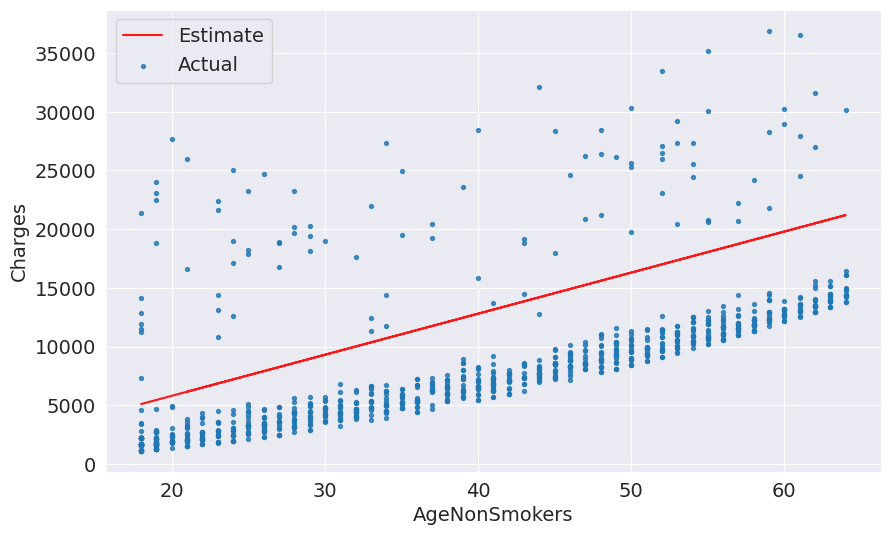

In [ ]:
# let's try different values of the w and b and  see the difference

try_parametersNonSmokers(350,-1200)


Here's how we can interpret the above number: On average, each element in the prediction differs from the actual target by \$6350.

The result is called the loss because it indicates how bad the model is at predicting the target variables. It represents information loss in the model: the lower the loss, the better the model.

RMSE Loss Smokers:  11557.899479925292


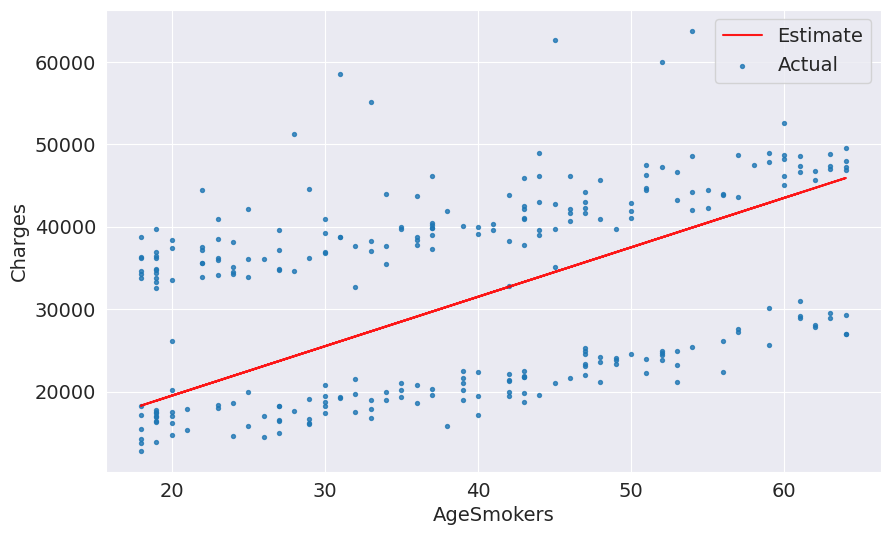

In [ ]:
try_parametersSmokers(600,7500)

#Linear Regression using Scikit-learn

Now we are going to use the Scikit-learn
library  and use its classLinearRegression class from scikit-learn to find the best fit line for "age" vs. "charges" using the ordinary least squares optimization technique

In [ ]:
from sklearn.linear_model import LinearRegression
model_NonSmokers=LinearRegression()





In [ ]:
# First let's apply linear Regression Model to the non-smokers

inputs_NonSmokers=non_smoker_df[['age']]
targets_NonSmokers=non_smoker_df.charges

print('Inputs_NonSmokers.shape: ',inputs_NonSmokers.shape)
print('Targets_NonSmokers.shape: ',targets_NonSmokers.shape)


Inputs_NonSmokers.shape:  (1064, 1)
Targets_NonSmokers.shape:  (1064,)


In [ ]:
# Now let's fit the model to the data.

model_NonSmokers.fit(inputs_NonSmokers,targets_NonSmokers)

LinearRegression()

In [ ]:
# We can now make the predictions using the model. Let's try predictiong the charges for the ages 23,37,61
model_NonSmokers.predict(np.array([[23],[37],[61]]))


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([ 4055.30443855,  7796.78921819, 14210.76312614])

Now Let's compare them with the scatter plot above.

> let compute the predictions for the entire set of inputs




In [ ]:
predictions_NonSmokers=model_NonSmokers.predict(inputs_NonSmokers)
predictions_NonSmokers


array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

In [ ]:
# let's now compute the RMSE loss to evaluate the model.
rmse(targets_NonSmokers,predictions_NonSmokers)


4662.505766636395

In [ ]:
rmse(targets_NonSmokers,predictions_NonSmokers)

4662.505766636395

We can see that our prediction is off by $4000 on average ,which is not too bad cosidering the fact that there are several outliers.

The parameters of the model  are stored in the coef_ and intercept_ properties.

In [ ]:
# w slope
model_NonSmokers.coef_

array([267.24891283])

In [ ]:
# b intercept
model_NonSmokers.intercept_

-2091.4205565650864

let's visualize the line created by the above parameters .


RMSE Loss NonSmokes:  4662.505766636395


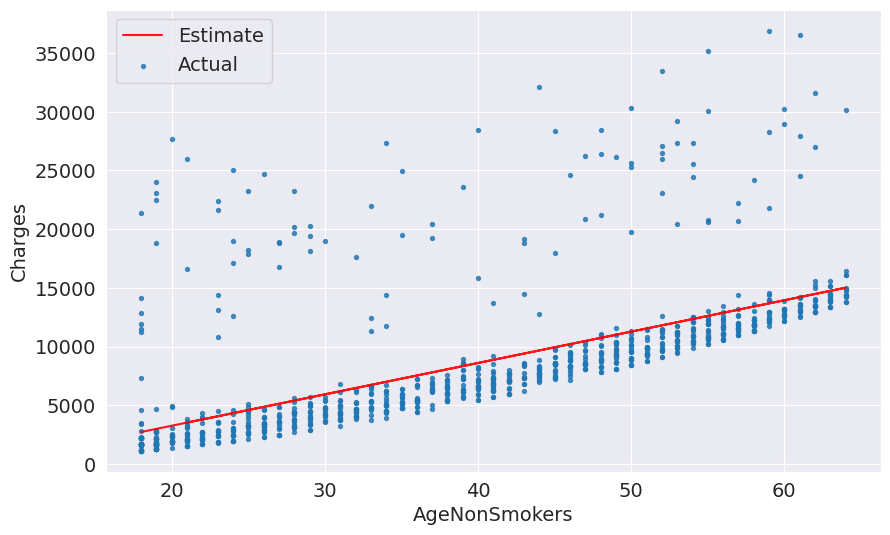

In [ ]:
try_parametersNonSmokers(model_NonSmokers.coef_,model_NonSmokers.intercept_)

Now we can see the line is quite close to the points. It is slightly above the cluster of points ,because it;s also trying to account for the outliers.


Now let's apply the Linear Regression model to Smokers also

In [ ]:
# Smokers

model_Smokers=LinearRegression()

inputs_Smokers=smoker_df[['age']]
targets_Smokers=smoker_df.charges

print('inputs_Smokers.shape: ',inputs_Smokers.shape)
print('targets_Smokers.shape: ',targets_Smokers.shape)


inputs_Smokers.shape:  (274, 1)
targets_Smokers.shape:  (274,)


In [ ]:
model_Smokers.fit(inputs_Smokers,targets_Smokers)


LinearRegression()

In [ ]:
# Now let's compute the predictions for the smokers
predictions_Smokers=model_Smokers.predict(inputs_Smokers)
predictions_Smokers

array([26093.642567  , 39218.85945773, 28535.54338388, 29451.25619021,
       30672.20659865, 29756.49379232, 27009.35537333, 28840.78098599,
       30977.44420076, 38608.38425351, 31282.68180287, 34945.53302819,
       31282.68180287, 37997.90904929, 25788.40496489, 36471.72103874,
       26398.88016911, 28840.78098599, 28535.54338388, 27009.35537333,
       31587.91940498, 34029.82022186, 37692.67144718, 38303.1466514 ,
       39829.33466195, 37387.43384507, 31893.15700709, 38913.62185562,
       26398.88016911, 39524.09705984, 29146.0185881 , 33724.58261975,
       26093.642567  , 30061.73139443, 30672.20659865, 29451.25619021,
       34335.05782397, 33114.10741553, 34945.53302819, 25788.40496489,
       29451.25619021, 33114.10741553, 25788.40496489, 39524.09705984,
       31282.68180287, 28535.54338388, 30977.44420076, 26093.642567  ,
       33114.10741553, 32503.63221131, 26093.642567  , 27314.59297544,
       39524.09705984, 25788.40496489, 39524.09705984, 36776.95864085,
      

In [ ]:
# let's also calculate the Rmse for the Smokers

rmse(targets_Smokers,predictions_Smokers)


10711.00334810241

We can see that our prediction is off by $10711 on average ,which is not too bad cosidering the fact that there are several outliers.

RMSE Loss Smokers:  10711.00334810241


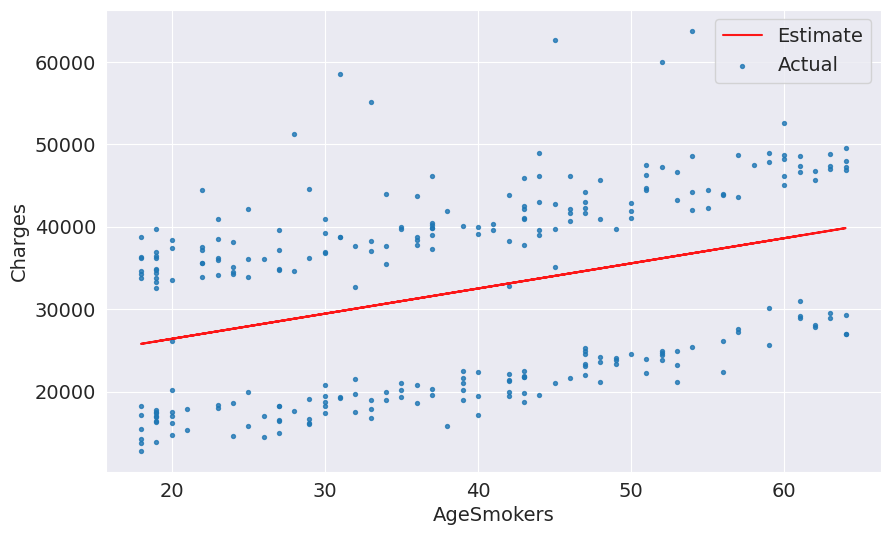

In [ ]:
# Now let's visualize the traind model with the actual output


try_parametersSmokers(model_Smokers.coef_,model_Smokers.intercept_)

Now this line seems better than before we the line is trying to adjust between the lower datasets  which the charges are below 30000 and the upper datasets  points which the charges are more than 30000

#Linear Regression using Multiple Features
So far, we've only used  the "age" feature to estimate "charges". Adding another feature like "bmi" is fairly straightforward. We simply assume the following relationship:

charges=w1 ×age+w2×bmi+b

We need to change just one line of code to include the BMI.

And now we are going to add all the important features

In [ ]:
# let's add  bmi ,children

inputs_NonSmokers,targets_NonSmokers=non_smoker_df[['age','bmi','children']],non_smoker_df['charges']

model_NonSmokers=LinearRegression().fit(inputs_NonSmokers,targets_NonSmokers)

# Generating predictions

predictions_NonSmokers=model_NonSmokers.predict(inputs_NonSmokers)

# Compute the loss to evalute the model
loss=rmse(targets_NonSmokers,predictions_NonSmokers)
print('Loss: ',loss)


Loss:  4608.470405038247


we don't see a big reduction in the loss, even though it's reduced from 4662 to 4608 than in the case of BMI.

Until Now we are predicting the charges for the smokers and non-smokers separately  Now let's predict the charges without separting instead predict on the whole dataset medical_df

In [ ]:
# Create inputs and targets
inputs, targets = medical_df[['age', 'bmi', 'children']], medical_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 11355.317901125973


#Using Categorical Features for Machine Learning
So far we've been using only numeric columns, since we can only perform computations with numbers. If we could use categorical columns like "smoker", we can train a single model for the entire dataset. since the correlation is very high for the smokers

#Binary Categories
The "smoker" category has just two values "yes" and "no". Let's create a new column "smoker_code" containing 0 for "no" and 1 for "yes".

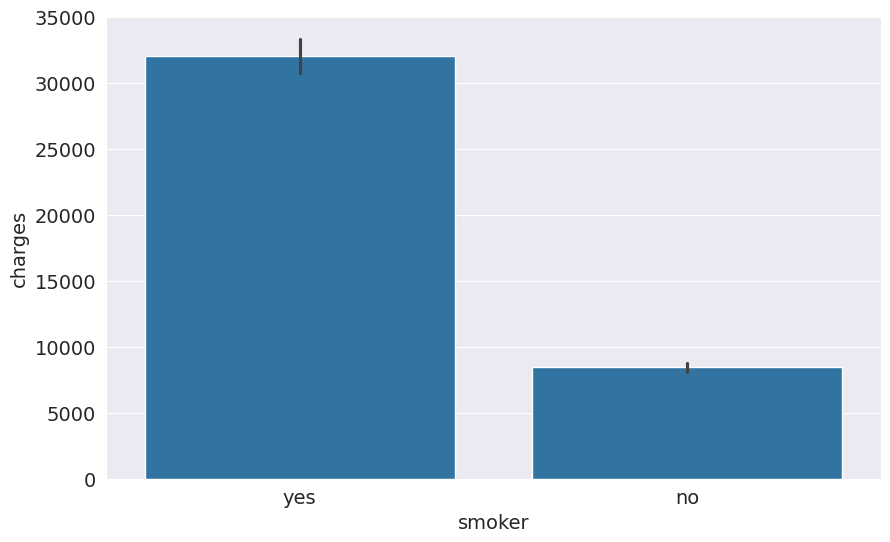

In [ ]:
sns.barplot(data=medical_df, x='smoker', y='charges');

In [ ]:
smoker_codes={'no':0,'yes':1}
medical_df['smoker_code']=medical_df.smoker.map(smoker_codes)


In [ ]:
medical_df.charges.corr(medical_df.smoker_code)


0.787251430498478

In [ ]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


We can now use the smoker_df column for linear regression.

In [ ]:
# Create inputs and targets
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_code']], medical_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6056.439217188081


The loss reduces from 11355 to 6056, almost by 50%! This is an important lesson: so we can say never ignore categorical data.

Let's try adding the "sex" column as well.

<Axes: xlabel='sex', ylabel='charges'>

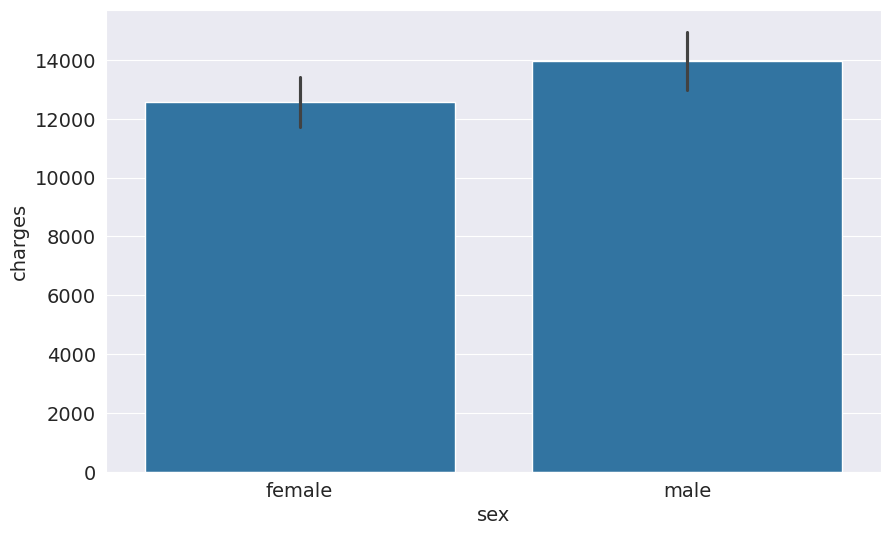

In [ ]:
sns.barplot(data=medical_df, x='sex', y='charges')

In [ ]:
sex_codes={'female':0,'male':1}
medical_df['sex_code']=medical_df.sex.map(sex_codes)

In [ ]:
medical_df.charges.corr(medical_df.sex_code)


0.057292062202025484

In [ ]:
# Create inputs and targets
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_code', 'sex_code']], medical_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6056.100708754546


this does have a significant impact on the loss.



#One-hot Encoding
The "region" column contains 4 values, so we'll need to use hot encoding and create a new column for each region.

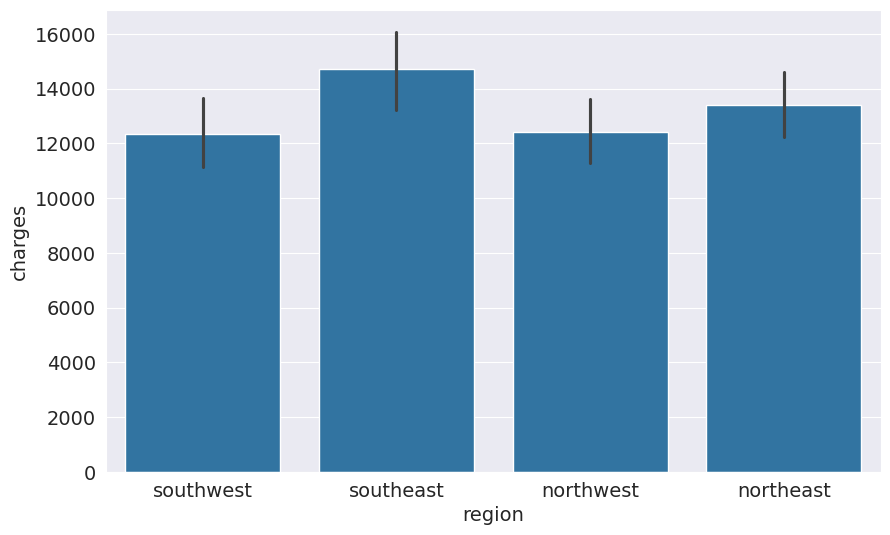

In [ ]:
sns.barplot(data=medical_df, x='region', y='charges');

In [ ]:
from sklearn import preprocessing
enc=preprocessing.OneHotEncoder()
enc.fit(medical_df[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [ ]:
one_hot=enc.transform(medical_df[['region']]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]])

In [ ]:
medical_df[['northeast','northwest','southeast','southwest']]=one_hot

In [ ]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [ ]:
import numpy as np
def mse(targets,predictions):
  return (np.mean(np.square(targets-predictions)))

In [ ]:
# Create inputs and targets
input_cols = ['age', 'bmi', 'children', 'smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
inputs, targets = medical_df[input_cols], medical_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6041.6796511744515


Once again, this leads to a fairly small reduction in the loss.

In [ ]:
loss=mse(targets,predictions)
print('loss: ',loss)

loss:  36501893.00741544


Now we can conclude that the most important feature are
1. Smoker
2. Age
3. BMI

# Creating a Test Set
Models like the one we've created in this  are designed to be used in the real world. It's common practice to set aside a small fraction of the data (e.g. 10%) just for testing and reporting the results of the model.

In [ ]:
# Create inputs and targets
input_cols1 = ['age', 'bmi',  'smoker_code']
inputs, targets = medical_df[input_cols1], medical_df['charges']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
inputs_train, inputs_test, targets_train, targets_test = train_test_split(inputs, targets, test_size=0.2,random_state=32)

# Create and train the model
model = LinearRegression().fit(inputs_train, targets_train)

# Generate predictions
predictions_test = model.predict(inputs_test)

# Compute loss to evalute the model
loss = rmse(targets_test, predictions_test)
print('Test Loss:', loss)

Test Loss: 5434.876737246597


In [ ]:
loss = mse(targets_test, predictions_test)
print('Test Loss:', loss)

Test Loss: 29537885.14906422


so we can confirm from this that we cannot use mse technique because of there are so many outliers it will cause our model worse  the loss for when mse is used is nearly four times then the rmse so it is suggested that when there are a lots of outliers and you want to ignore them use rmse instead of mse


In [ ]:
model.coef_

array([  258.85796729,   325.47136812, 23695.66317124])

In [ ]:
model.intercept_

-11659.365468721475

In [ ]:
medical_df


,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [ ]:
# let's compare this with the training loss.

# Generate predictions
predictions_train = model.predict(inputs_train)

# Compute loss to evalute the model
loss = rmse(targets_train, predictions_train)
print('Training Loss:', loss)

Training Loss: 6235.61269512126


In [ ]:
from sklearn.metrics import r2_score

# Assuming y_true and y_pred are your actual and predicted values
r_squared = r2_score(targets_train, predictions_train)
print(f'R-squared: {r_squared}')

R-squared: 0.739595882836926


In [ ]:
medical_df.describe()

,age,bmi,children,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265,0.204783,0.505232,0.242152,0.242900,0.272048,0.242900
std,14.049960,6.098187,1.205493,12110.011237,0.403694,0.500160,0.428546,0.428995,0.445181,0.428995
min,18.000000,15.960000,0.000000,1121.873900,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,26.296250,0.000000,4740.287150,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,39.000000,30.400000,1.000000,9382.033000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,51.000000,34.693750,2.000000,16639.912515,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,64.000000,53.130000,5.000000,63770.428010,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
